## LightGBM

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [44]:
df = pd.read_csv("feature_engineered_dataset.csv")

print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist()[:20])

Dataset Shape: (140909, 41)
Columns: ['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'od_start_time', 'od_end_time', 'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor']


In [46]:
df = df.dropna(subset=["actual_time"])

X = df.drop(columns=["actual_time"])
y = df["actual_time"]

non_numeric_cols = X.select_dtypes(include=["object"]).columns
X = X.drop(columns=non_numeric_cols)

print("Remaining Numeric Feature Columns:", X.shape[1])

X = X.replace([np.inf, -np.inf], np.nan)


Remaining Numeric Feature Columns: 27


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (112727, 27)
Testing set shape: (28182, 27)


In [49]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),  
    ("model", LGBMRegressor(random_state=42))      
])

pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,boosting_type,'gbdt'


In [50]:
y_pred = pipeline.predict(X_test)

In [51]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Manual RMSE calculation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Metrics:
RMSE: 8.0591
MAE: 4.3685
R² Score: 0.9998


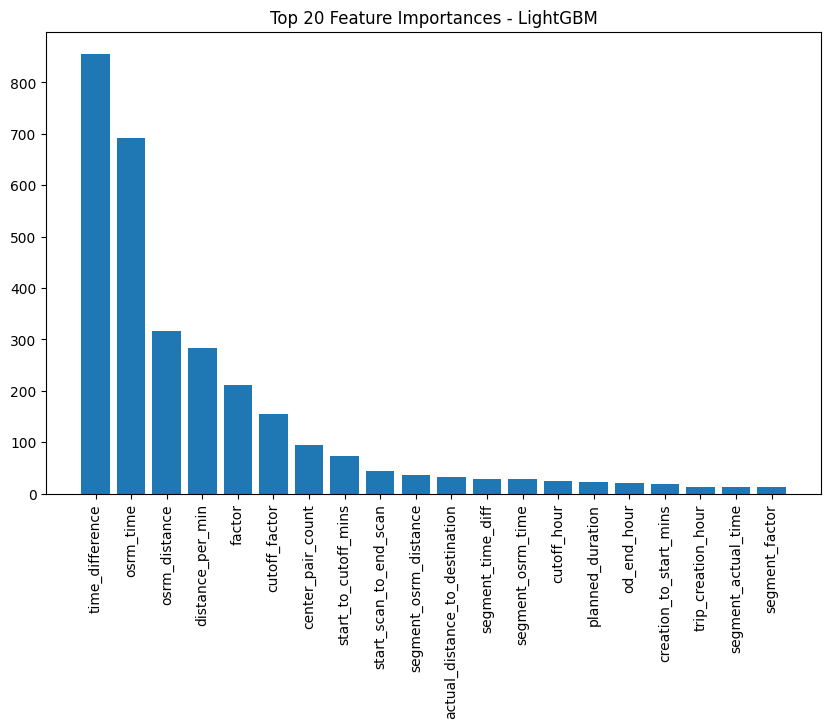

In [52]:
import matplotlib.pyplot as plt

model = pipeline.named_steps["model"]
importances = model.feature_importances_
feature_names = X.columns
 
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances - LightGBM")
plt.bar(range(20), importances[sorted_idx][:20])
plt.xticks(range(20), feature_names[sorted_idx][:20], rotation=90)
plt.show()


In [54]:
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train Metrics:")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"R² Score: {train_r2:.4f}")

print("\nTest Metrics:")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"R² Score: {test_r2:.4f}")


Train Metrics:
RMSE: 7.1787
MAE: 4.1700
R² Score: 0.9999

Test Metrics:
RMSE: 8.0591
MAE: 4.3685
R² Score: 0.9998


## XGBoost

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

df = pd.read_csv("feature_engineered_dataset.csv")
df = df.sample(frac=0.1, random_state=42)

target = 'actual_time'
df = df[np.isfinite(df[target])]
df = df.dropna(subset=[target])


In [ ]:
X = df.drop(columns=[target])
y = np.log1p(df[target])

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

X.replace([np.inf, -np.inf], np.nan, inplace=True)
X = X.dropna(axis=0, how='any', subset=numeric_cols)
y = y[X.index]


In [39]:
X = df.drop(columns=[target])
y = np.log1p(df[target])

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

X.replace([np.inf, -np.inf], np.nan, inplace=True)
X = X.dropna(axis=0, how='any', subset=numeric_cols)
y = y[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [40]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])


In [41]:
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBRegressor(objective='reg:squarederror', random_state=42))
])

param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [3],
    'model__learning_rate': [0.03, 0.05],
    'model__subsample': [0.7],
    'model__colsample_bytree': [0.7],
    'model__reg_alpha': [5, 10],
    'model__reg_lambda': [10, 20]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 16 candidates, totalling 48 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.7], 'model__learning_rate': [0.03, 0.05], 'model__max_depth': [3], 'model__n_estimators': [200, 300], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [42]:
y_pred_train_log = grid_search.predict(X_train)
y_pred_test_log = grid_search.predict(X_test)

y_pred_train = np.expm1(y_pred_train_log)
y_pred_test = np.expm1(y_pred_test_log)
y_train_actual = np.expm1(y_train)
y_test_actual = np.expm1(y_test)

rmse_train = np.sqrt(mean_squared_error(y_train_actual, y_pred_train))
mae_train = mean_absolute_error(y_train_actual, y_pred_train)
r2_train = r2_score(y_train_actual, y_pred_train)

rmse_test = np.sqrt(mean_squared_error(y_test_actual, y_pred_test))
mae_test = mean_absolute_error(y_test_actual, y_pred_test)
r2_test = r2_score(y_test_actual, y_pred_test)

print("Best Params:", grid_search.best_params_)
print("Train Metrics:")
print(f"RMSE: {rmse_train:.2f}")
print(f"MAE: {mae_train:.2f}")
print(f"R² Score: {r2_train:.4f}")
print("Test Metrics:")
print(f"RMSE: {rmse_test:.2f}")
print(f"MAE: {mae_test:.2f}")
print(f"R² Score: {r2_test:.4f}")


Best Params: {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__reg_alpha': 5, 'model__reg_lambda': 10, 'model__subsample': 0.7}
Train Metrics:
RMSE: 39.18
MAE: 11.92
R² Score: 0.9960
Test Metrics:
RMSE: 34.98
MAE: 11.37
R² Score: 0.9966


## Comparision

Model Performance Comparison:

     Metric  XGBoost Train  XGBoost Test  LightGBM Train  LightGBM Test
0      RMSE         39.180       34.9800          7.1787         8.0591
1       MAE         11.920       11.3700          4.1700         4.3685
2  R² Score          0.996        0.9966          0.9999         0.9998


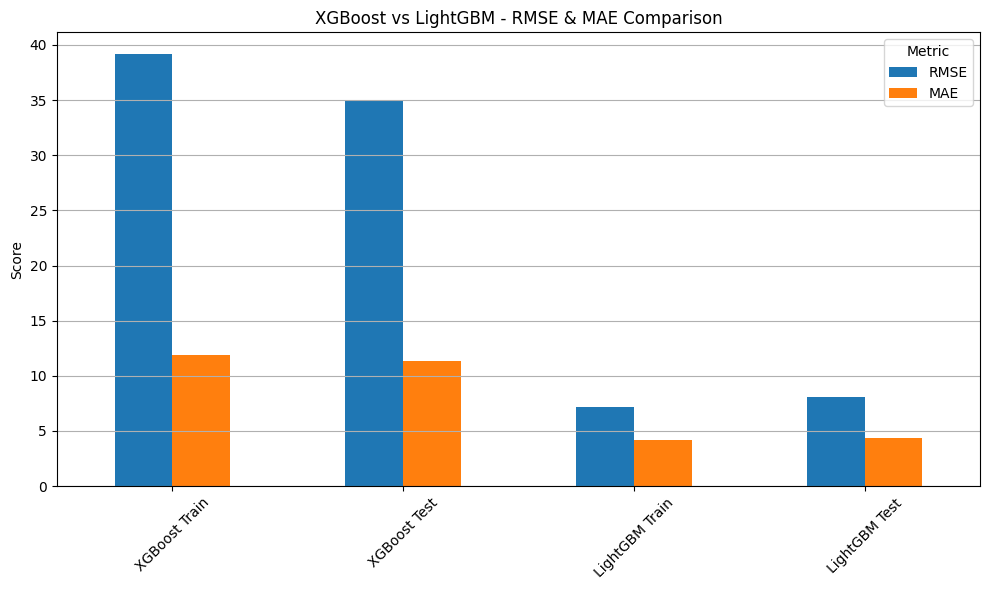

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# Create the comparison data
data = {
    "Metric": ["RMSE", "MAE", "R² Score"],
    "XGBoost Train": [39.18, 11.92, 0.9960],
    "XGBoost Test": [34.98, 11.37, 0.9966],
    "LightGBM Train": [7.1787, 4.1700, 0.9999],
    "LightGBM Test": [8.0591, 4.3685, 0.9998]
}

# Create DataFrame
df_compare = pd.DataFrame(data)

# Display table
print("Model Performance Comparison:\n")
print(df_compare)

# Optional: Plot bar chart for RMSE and MAE
metrics_to_plot = ["RMSE", "MAE"]
df_plot = df_compare[df_compare["Metric"].isin(metrics_to_plot)].set_index("Metric")

df_plot.T.plot(kind='bar', figsize=(10, 6))
plt.title("XGBoost vs LightGBM - RMSE & MAE Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()
